# Notebook 02 — Entrenamiento del Modelo
## Transfer Learning con ResNet-18 para Clasificación SEM

**Modelo:** ResNet-18 pre-entrenado en ImageNet  
**Tarea:** Clasificación binaria — Nanopartículas (0D) vs Nanohilos (1D)  
**Estrategia:** Fine-tuning en 2 fases

---

## Contenido
1. Cargar configuración del dataset
2. Configurar modelo ResNet-18
3. Fase 1: Entrenar solo capa FC
4. Fase 2: Fine-tuning completo
5. Curvas de aprendizaje
6. Guardar modelo entrenado

In [1]:
# ============================================================
# WARM-UP: Imports y configuración
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import json
import time
from pathlib import Path
from tqdm import tqdm

# Cargar configuración del dataset
PROJECT_ROOT = Path('..').resolve()
config_path = PROJECT_ROOT / 'reports' / 'dataset_config.json'
with open(config_path) as f:
    cfg = json.load(f)

DATA_PROCESSED = Path(cfg['data_processed'])
CLASSES = cfg['classes']
IMAGENET_MEAN = cfg['imagenet_mean']
IMAGENET_STD = cfg['imagenet_std']
BATCH_SIZE = cfg['batch_size']

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Clases: {CLASSES}')
print(f'Dataset: {DATA_PROCESSED}')

Device: cuda
Clases: ['nanoparticles', 'nanowires']
Dataset: C:\IA Nanotecnología\Antigravity-Nano-Research-Multiagentic-Core-main\educational_content\Proyecto final\data\processed


In [2]:
# ============================================================
# DATALOADERS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(str(DATA_PROCESSED / 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(str(DATA_PROCESSED / 'val'),   transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')

Train: 482 | Val: 103


## 2. Configurar ResNet-18

Usamos **Transfer Learning**: cargamos ResNet-18 pre-entrenado en ImageNet (1.2M imágenes, 1000 clases) y reemplazamos la última capa FC para clasificación binaria (2 clases).

$$\text{ResNet-18}_{\text{ImageNet}} \rightarrow \text{Freeze backbone} \rightarrow \text{Train FC(512, 2)} \rightarrow \text{Unfreeze} \rightarrow \text{Fine-tune all}$$

In [3]:
# ============================================================
# MODELO: ResNet-18 con Transfer Learning
# ============================================================
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Congelar todas las capas
for param in model.parameters():
    param.requires_grad = False

# Reemplazar capa FC final: 512 → 2 clases
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)

model = model.to(device)

# Contar parámetros
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales:     {total:,}')
print(f'Parámetros entrenables: {trainable:,} (solo FC)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\foxyv/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [01:08<00:00, 681kB/s] 


Parámetros totales:     11,177,538
Parámetros entrenables: 1,026 (solo FC)


In [4]:
# ============================================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='  Val', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


## 3. Fase 1: Entrenar solo capa FC (10 epochs)

In [5]:
# ============================================================
# FASE 1: Solo FC — lr=1e-3, 10 epochs
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'phase': []}
best_val_acc = 0.0
MODEL_PATH = PROJECT_ROOT / 'models' / 'best_sem_classifier.pth'

print('=== FASE 1: Entrenamiento capa FC ===')
EPOCHS_P1 = 10

for epoch in range(EPOCHS_P1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(v_loss)
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['phase'].append('FC')
    
    lr = optimizer.param_groups[0]['lr']
    marker = ''
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), MODEL_PATH)
        marker = ' ★ best'
    
    print(f'  Epoch {epoch+1:2d}/{EPOCHS_P1} | '
          f'Train: {t_loss:.4f} ({t_acc:.1%}) | '
          f'Val: {v_loss:.4f} ({v_acc:.1%}) | '
          f'LR: {lr:.2e}{marker}')

print(f'\nFase 1 completada. Mejor val accuracy: {best_val_acc:.1%}')

=== FASE 1: Entrenamiento capa FC ===


  Epoch  1/10 | Train: 0.2614 (91.5%) | Val: 0.1912 (95.1%) | LR: 1.00e-03 ★ best


  Epoch  2/10 | Train: 0.1898 (95.0%) | Val: 0.1303 (95.1%) | LR: 1.00e-03


  Epoch  3/10 | Train: 0.1502 (95.4%) | Val: 0.1167 (95.1%) | LR: 1.00e-03


  Epoch  4/10 | Train: 0.1251 (95.4%) | Val: 0.1061 (95.1%) | LR: 1.00e-03


...

  Epoch  6/10 | Train: 0.1213 (95.9%) | Val: 0.0863 (98.1%) | LR: 1.00e-03 ★ best


  Epoch  7/10 | Train: 0.1241 (95.9%) | Val: 0.0808 (96.1%) | LR: 1.00e-03


  Epoch  8/10 | Train: 0.0912 (96.1%) | Val: 0.0787 (98.1%) | LR: 1.00e-03


  Epoch  9/10 | Train: 0.0956 (97.1%) | Val: 0.0778 (98.1%) | LR: 1.00e-03


  Epoch 10/10 | Train: 0.0853 (96.7%) | Val: 0.0747 (98.1%) | LR: 1.00e-03

Fase 1 completada. Mejor val accuracy: 98.1%


## 4. Fase 2: Fine-tuning completo (10 epochs)

In [6]:
# ============================================================
# FASE 2: Fine-tuning completo — lr=1e-5, 10 epochs
# ============================================================
# Descongelar todas las capas
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {trainable:,} (todo el modelo)')

optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

print('\n=== FASE 2: Fine-tuning completo ===')
EPOCHS_P2 = 10

for epoch in range(EPOCHS_P2):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(v_loss)
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['phase'].append('FT')
    
    lr = optimizer.param_groups[0]['lr']
    marker = ''
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), MODEL_PATH)
        marker = ' ★ best'
    
    print(f'  Epoch {epoch+1:2d}/{EPOCHS_P2} | '
          f'Train: {t_loss:.4f} ({t_acc:.1%}) | '
          f'Val: {v_loss:.4f} ({v_acc:.1%}) | '
          f'LR: {lr:.2e}{marker}')

print(f'\nEntrenamiento completo. Mejor val accuracy: {best_val_acc:.1%}')
print(f'Modelo guardado en: {MODEL_PATH}')

Parámetros entrenables: 11,177,538 (todo el modelo)

=== FASE 2: Fine-tuning completo ===


  Epoch  1/10 | Train: 0.0991 (96.7%) | Val: 0.0691 (98.1%) | LR: 1.00e-05


  Epoch  2/10 | Train: 0.0741 (98.3%) | Val: 0.0768 (98.1%) | LR: 1.00e-05


  Epoch  3/10 | Train: 0.0668 (98.1%) | Val: 0.0771 (98.1%) | LR: 1.00e-05


  Epoch  4/10 | Train: 0.0538 (98.5%) | Val: 0.0701 (98.1%) | LR: 1.00e-05


...

  Epoch  6/10 | Train: 0.0447 (98.1%) | Val: 0.0734 (98.1%) | LR: 5.00e-06


  Epoch  7/10 | Train: 0.0531 (98.1%) | Val: 0.0770 (98.1%) | LR: 5.00e-06


  Epoch  8/10 | Train: 0.0376 (99.6%) | Val: 0.0718 (98.1%) | LR: 5.00e-06


  Epoch  9/10 | Train: 0.0429 (99.2%) | Val: 0.0639 (99.0%) | LR: 5.00e-06 ★ best


  Epoch 10/10 | Train: 0.0381 (98.8%) | Val: 0.0710 (99.0%) | LR: 5.00e-06

Entrenamiento completo. Mejor val accuracy: 99.0%
Modelo guardado en: C:\IA Nanotecnología\Antigravity-Nano-Research-Multiagentic-Core-main\educational_content\Proyecto final\models\best_sem_classifier.pth


## 5. Curvas de Aprendizaje

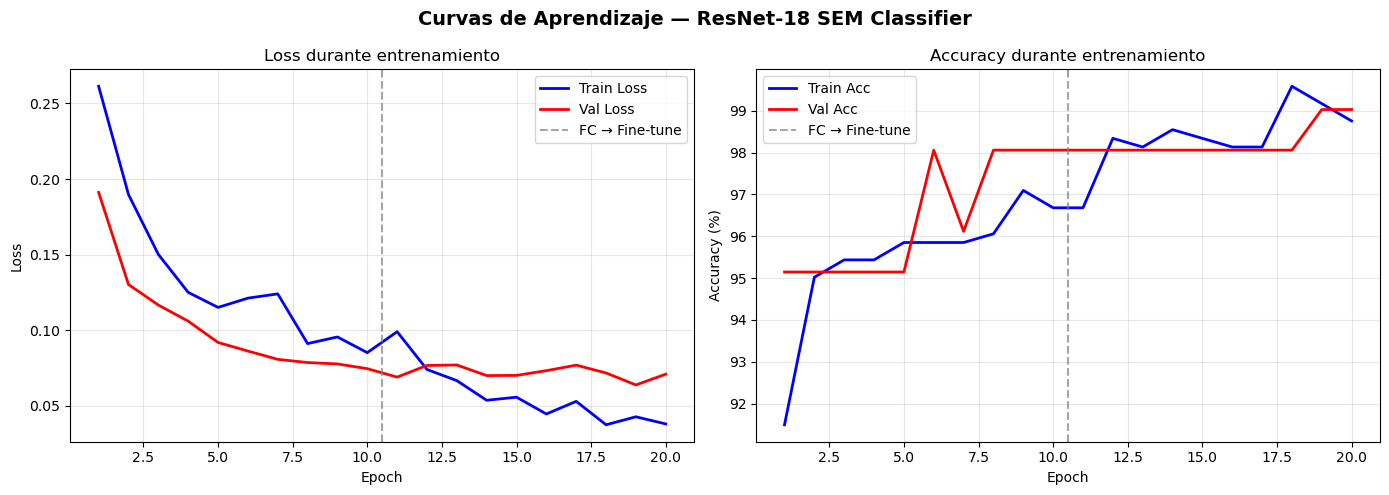

In [7]:
# ============================================================
# CURVAS DE APRENDIZAJE
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)
phase_boundary = EPOCHS_P1 + 0.5

# Loss
ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1.axvline(x=phase_boundary, color='gray', linestyle='--', alpha=0.7, label='FC → Fine-tune')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss durante entrenamiento')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, [a*100 for a in history['train_acc']], 'b-', label='Train Acc', linewidth=2)
ax2.plot(epochs, [a*100 for a in history['val_acc']], 'r-', label='Val Acc', linewidth=2)
ax2.axvline(x=phase_boundary, color='gray', linestyle='--', alpha=0.7, label='FC → Fine-tune')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy durante entrenamiento')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — ResNet-18 SEM Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'reports' / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# GUARDAR HISTORIAL DE ENTRENAMIENTO
# ============================================================
training_info = {
    'model': 'ResNet-18 (ImageNet pretrained)',
    'epochs_fc': EPOCHS_P1,
    'epochs_finetune': EPOCHS_P2,
    'best_val_accuracy': best_val_acc,
    'device': str(device),
    'model_path': str(MODEL_PATH),
    'history': history,
}

with open(PROJECT_ROOT / 'reports' / 'training_history.json', 'w') as f:
    json.dump(training_info, f, indent=2)

print(f'Historial guardado.')
print(f'\n→ Continuar con: 03_evaluation_gradcam.ipynb')

Historial guardado.

→ Continuar con: 03_evaluation_gradcam.ipynb
